In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

#  Loading the Dataset

In [3]:
df = pd.read_csv("../data/housing.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries

Exploring the dataset 

Missing values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Ocean Proximity categories:
 ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


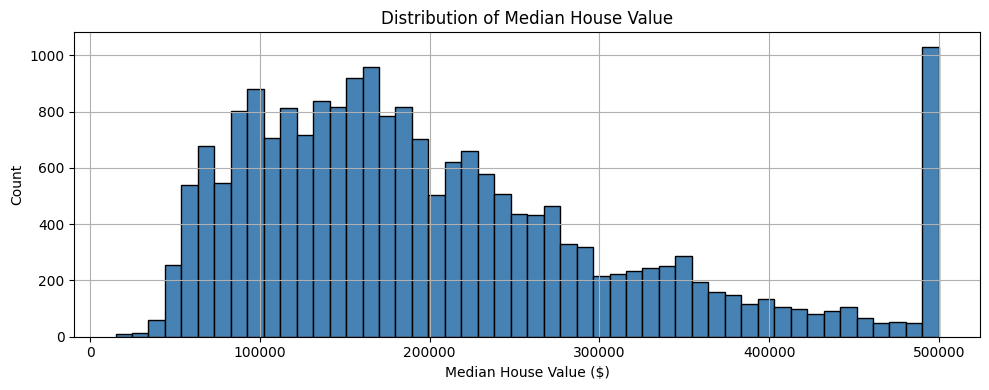

In [4]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Check ocean_proximity categories
print("\nOcean Proximity categories:\n", df['ocean_proximity'].value_counts())

# Visualize house value distribution
plt.figure(figsize=(10, 4))
df['median_house_value'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Handle Missing Values

In [5]:
# Fill the 207 missing total_bedrooms with the median
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Confirm no more missing values
print("Missing after fix:\n", df.isnull().sum())
# All should show 0

Missing after fix:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Create Classification Target

Low cut  (33rd percentile): $140,600
High cut (66th percentile): $228,000

Class distribution:
price_category
High      7016
Low       6828
Medium    6796
Name: count, dtype: int64


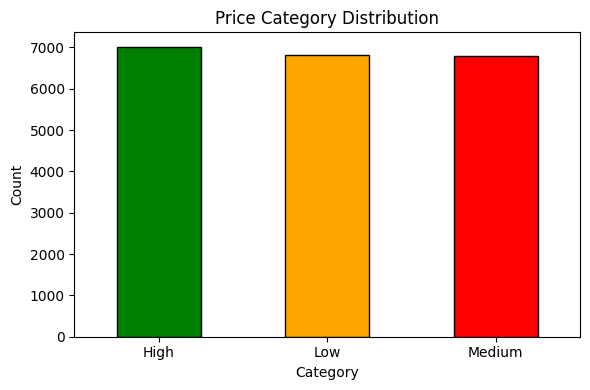

In [6]:
# Get the 33rd and 66th percentile cut points
low_cut  = df['median_house_value'].quantile(0.33)
high_cut = df['median_house_value'].quantile(0.66)

print(f"Low cut  (33rd percentile): ${low_cut:,.0f}")
print(f"High cut (66th percentile): ${high_cut:,.0f}")

# Bin into 3 classes
bins   = [0, low_cut, high_cut, df['median_house_value'].max() + 1]
labels = ['Low', 'Medium', 'High']

df['price_category'] = pd.cut(
    df['median_house_value'],
    bins=bins,
    labels=labels
)

print("\nClass distribution:")
print(df['price_category'].value_counts())

# Visualize class balance
df['price_category'].value_counts().plot(
    kind='bar', color=['green','orange','red'],
    edgecolor='black', figsize=(6,4)
)
plt.title('Price Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 Encode ocean_proximity

In [7]:
# One-hot encode — converts text categories to 0/1 columns
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# See the new columns created
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'price_category', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


Define Features (X) and Target (y)

In [8]:
# Drop the original continuous price AND the new label from features
X = df.drop(columns=['median_house_value', 'price_category'])
y = df['price_category']

print("Feature columns:", X.columns.tolist())
print("X shape:", X.shape)   # (20640, 13)
print("y shape:", y.shape)   # (20640,)

Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
X shape: (20640, 12)
y shape: (20640,)


Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% → ~4,128 test samples
    random_state=42,
    stratify=y          # ensures Low/Medium/High ratio is same in train & test
)

print("X_train:", X_train.shape)  # (16512, 13)
print("X_test :", X_test.shape)   # (4128,  13)

X_train: (16512, 12)
X_test : (4128, 12)


Scale Features

In [10]:
# SVM uses Euclidean distance — unscaled features like total_rooms (thousands)
# will dominate over median_income (single digits). Must normalize!

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std from train only
X_test_scaled  = scaler.transform(X_test)       # apply same scaling to test

print("Scaling done. Mean ~0, Std ~1 per feature.")

Scaling done. Mean ~0, Std ~1 per feature.


# A. Train an SVM classifier using at least two kernels (e.g., Linear and RBF) 

Train Linear SVM

In [11]:
print("Training Linear SVM... (may take ~1-2 minutes on 16k rows)")

svm_linear = SVC(
    kernel='linear',
    C=1.0,           # default regularization
    random_state=42
)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
print("Linear SVM done.")

Training Linear SVM... (may take ~1-2 minutes on 16k rows)
Linear SVM done.


Train RBF SVM

In [12]:
print("Training RBF SVM... (may take ~2-3 minutes)")

svm_rbf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',   # gamma = 1 / (n_features * X.var()) — auto scaled
    random_state=42
)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
print("RBF SVM done.")

Training RBF SVM... (may take ~2-3 minutes)
RBF SVM done.


# B. Explain Margin maximization, Role of parameter C, Role of kernel functions 

# C. Evaluate the classifier using: Accuracy, Precision, Recall, F1-Score

In [13]:
#evaluating both methods

def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*50}")
    print(f"   {name}")
    print(f"{'='*50}")
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nDetailed Report:\n")
    print(classification_report(y_true, y_pred,
                                target_names=['Low','Medium','High']))

evaluate_model("Linear Kernel SVM", y_test, y_pred_linear)
evaluate_model("RBF Kernel SVM",    y_test, y_pred_rbf)


   Linear Kernel SVM
  Accuracy  : 0.7306  (73.06%)
  Precision : 0.7328
  Recall    : 0.7306
  F1-Score  : 0.7316

Detailed Report:

              precision    recall  f1-score   support

         Low       0.80      0.79      0.79      1403
      Medium       0.78      0.77      0.78      1366
        High       0.61      0.64      0.63      1359

    accuracy                           0.73      4128
   macro avg       0.73      0.73      0.73      4128
weighted avg       0.73      0.73      0.73      4128


   RBF Kernel SVM
  Accuracy  : 0.7524  (75.24%)
  Precision : 0.7553
  Recall    : 0.7524
  F1-Score  : 0.7536

Detailed Report:

              precision    recall  f1-score   support

         Low       0.83      0.79      0.81      1403
      Medium       0.79      0.79      0.79      1366
        High       0.64      0.67      0.66      1359

    accuracy                           0.75      4128
   macro avg       0.75      0.75      0.75      4128
weighted avg       0.76   

Confusion Matrix — False Positives & Negatives

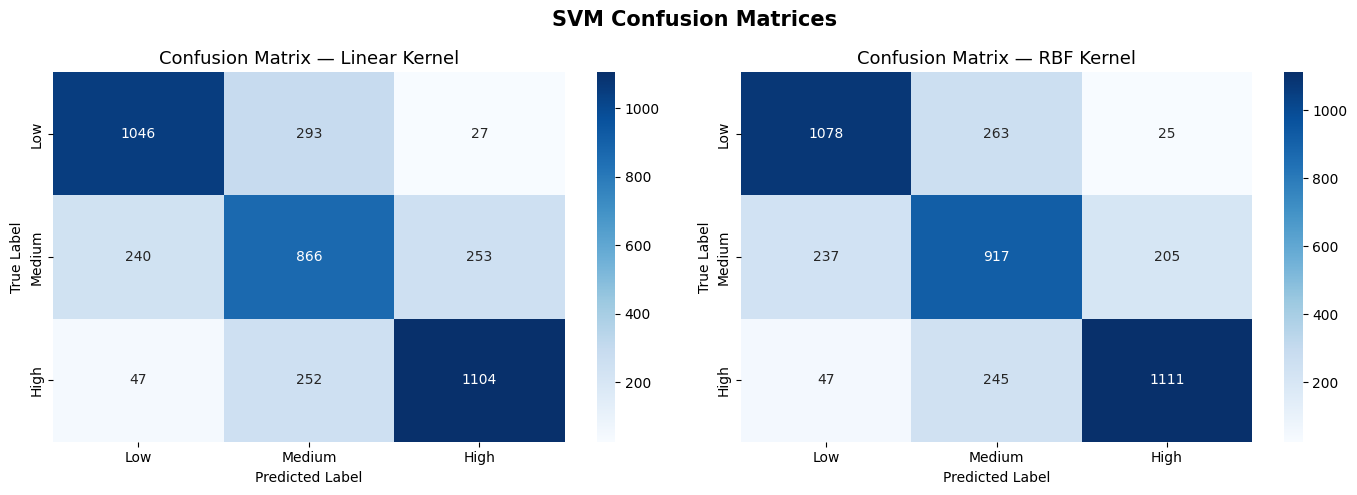

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_linear, y_pred_rbf],
    ['Linear Kernel', 'RBF Kernel']
):
    cm = confusion_matrix(y_test, y_pred,
                          labels=['Low', 'Medium', 'High'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Low','Medium','High'],
        yticklabels=['Low','Medium','High'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('SVM Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Side-by-Side Comparison Table

   Metric  Linear SVM  RBF SVM
 Accuracy      0.7306   0.7524
Precision      0.7328   0.7553
   Recall      0.7306   0.7524
 F1-Score      0.7316   0.7536


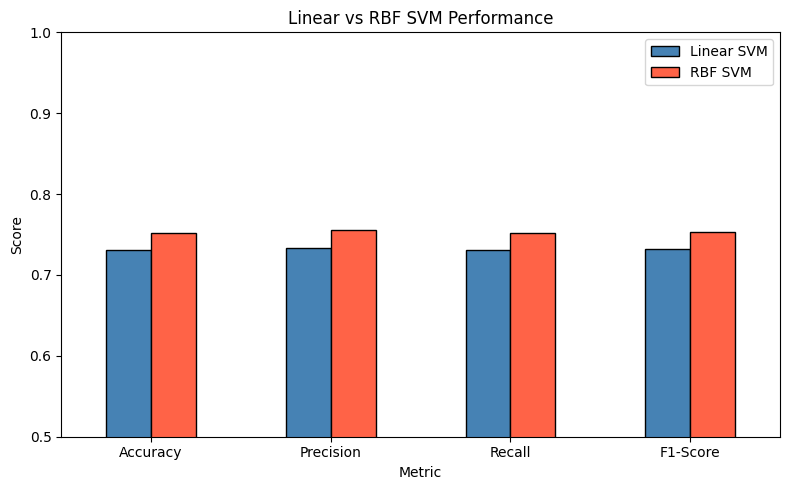

In [15]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Linear SVM': [
        round(accuracy_score(y_test, y_pred_linear), 4),
        round(precision_score(y_test, y_pred_linear, average='weighted'), 4),
        round(recall_score(y_test, y_pred_linear, average='weighted'), 4),
        round(f1_score(y_test, y_pred_linear, average='weighted'), 4)
    ],
    'RBF SVM': [
        round(accuracy_score(y_test, y_pred_rbf), 4),
        round(precision_score(y_test, y_pred_rbf, average='weighted'), 4),
        round(recall_score(y_test, y_pred_rbf, average='weighted'), 4),
        round(f1_score(y_test, y_pred_rbf, average='weighted'), 4)
    ]
})

print(comparison.to_string(index=False))

# Bar chart comparison
comparison.set_index('Metric').plot(
    kind='bar', figsize=(8, 5),
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
plt.title('Linear vs RBF SVM Performance')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# D. Interpret results: Discuss false positives and false negatives 

In [16]:
# Create a results dataframe for analysis
results_df = X_test.copy()
results_df['True_Label']      = y_test.values
results_df['Predicted_RBF']   = y_pred_rbf

# --- FALSE POSITIVES for "High" class ---
# (Predicted High but actually wasn't)
fp_high = results_df[
    (results_df['Predicted_RBF'] == 'High') &
    (results_df['True_Label']    != 'High')
]

# --- FALSE NEGATIVES for "High" class ---
# (Actually High but predicted something else)
fn_high = results_df[
    (results_df['True_Label']    == 'High') &
    (results_df['Predicted_RBF'] != 'High')
]

print(f"False Positives (predicted High, was not): {len(fp_high)}")
print(f"False Negatives (was High, not predicted): {len(fn_high)}")

print("\nSample False Positives:")
print(fp_high[['median_income', 'housing_median_age',
               'True_Label', 'Predicted_RBF']].head(5))

print("\nSample False Negatives:")
print(fn_high[['median_income', 'housing_median_age',
               'True_Label', 'Predicted_RBF']].head(5))

False Positives (predicted High, was not): 230
False Negatives (was High, not predicted): 292

Sample False Positives:
       median_income  housing_median_age True_Label Predicted_RBF
18919         4.6776                34.0     Medium          High
4262          1.5100                30.0     Medium          High
17988         4.0962                20.0     Medium          High
16714         4.3218                17.0     Medium          High
11089         6.0224                38.0     Medium          High

Sample False Negatives:
       median_income  housing_median_age True_Label Predicted_RBF
8552          2.4250                40.0       High        Medium
19060         2.7457                37.0       High           Low
9965          4.6379                29.0       High        Medium
17518         2.8042                35.0       High        Medium
15383         5.0507                14.0       High        Medium
